In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Select the CPU and TensorFlow's backend.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["KERAS_BACKEND"] = "tensorflow"
# os.environ["KERAS_BACKEND"] = "jax"
# os.environ["KERAS_BACKEND"] = "torch"

import keras
print(keras.__version__)
# Fixed random seed for repeatability.

seed = 42
keras.utils.set_random_seed(seed)
np.random.seed(seed)

import warnings
warnings.filterwarnings("ignore")


import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# To load the data
import tensorflow_datasets as tfds

(train_split, val_split, test_data), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True,
    with_info=True
)

3.12.0


In [21]:
import tensorflow as tf

def dataset_to_numpy(dataset, img_size=(128, 128)):
    images = []
    labels = []
    
    for img, label in tfds.as_numpy(dataset):
        img_resized = tf.image.resize(img, img_size).numpy().astype(np.uint8)
        images.append(img_resized)
        labels.append(label)

    return np.array(images), np.array(labels)

IMG_SHAPE = (256, 256)

x_train, y_train = dataset_to_numpy(train_split, img_size=IMG_SHAPE)
x_val, y_val     = dataset_to_numpy(val_split, img_size=IMG_SHAPE)
x_test, y_test   = dataset_to_numpy(test_data, img_size=IMG_SHAPE)

labels = {
    0 : "Abyssinian",
    1: "american_bulldog",
    2: "american_pit_bull_terrier",
    3: "basset_hound",
    4: "beagle",
    5: "Bengal",
    6: "Birman",
    7: "Bombay",
    8: "boxer",
    9: "British_Shorthair",
    10: "chihuahua",
    11: "Egyptian_Mau",
    12: "english_cocker_spaniel",
    13: "english_setter",
    14: "german_shorthaired",
    15: "great_pyrenees",
    16: "havanese",
    17: "japanese_chin",
    18: "keeshond",
    19: "leonberger",
    20: "Maine_Coon",
    21: "miniature_pinscher",
    22: "newfoundland",
    23: "Persian",
    24: "pomeranian",
    25: "pug",
    26: "Ragdoll",
    27: "Russian_Blue",
    28: "saint_bernard",
    29: "samoyed",
    30: "scottish_terrier",
    31: "shiba_inu",
    32: "Siamese",
    33: "Sphynx",
    34: "staffordshire_bull_terrier",
    35: "wheaten_terrier",
    36: "yorkshire_terrier"
}

n_train, w_train, h_train, channels = x_train.shape
n_test, w_test, h_test, channels_test = x_test.shape
unique_labels = np.unique(y_train)
n_classes = len(unique_labels)

x_train = x_train.astype('float') / np.max(x_train)
x_test = x_test.astype('float') / np.max(x_test)

from keras import Sequential
from keras.layers import (Input, Conv2D, MaxPooling2D, Dense, 
                          Flatten, Dropout, BatchNormalization,
                          RandomFlip, RandomRotation, RandomZoom)

input_shape = x_train.shape[1:]

In [22]:
model = Sequential([
    # Input layer.
        Input(shape = input_shape),

        Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(filters = 64, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(filters = 128, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),
        Dense(units = n_classes, activation = "softmax")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,659,365 (128.40 MB)

 Trainable params: 33,658,405 (128.40 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy

opt = Adam(learning_rate = 1e-3)
loss_fcn = SparseCategoricalCrossentropy()

model.compile(loss = loss_fcn,
              optimizer = opt, 
              metrics = ["accuracy"])

batch_size = 128
epochs = 6
val_split_percentage = 0.25

model.fit(x_train, 
          y_train, 
          batch_size = batch_size, 
          epochs = epochs, 
          validation_split = val_split_percentage);

Epoch 1/6
12/18 ━━━━━━━━━━━━━━━━━━━━ 47s 8s/step - accuracy: 0.2762 - loss: 2.8461

KeyboardInterrupt: 

115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.0488 - loss: 5.7351
The test loss is 5.7351, the test accuracy is 0.0488.
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step
Test Input Shape: (3669, 128, 128, 3) Test output shape: (3669, 37)


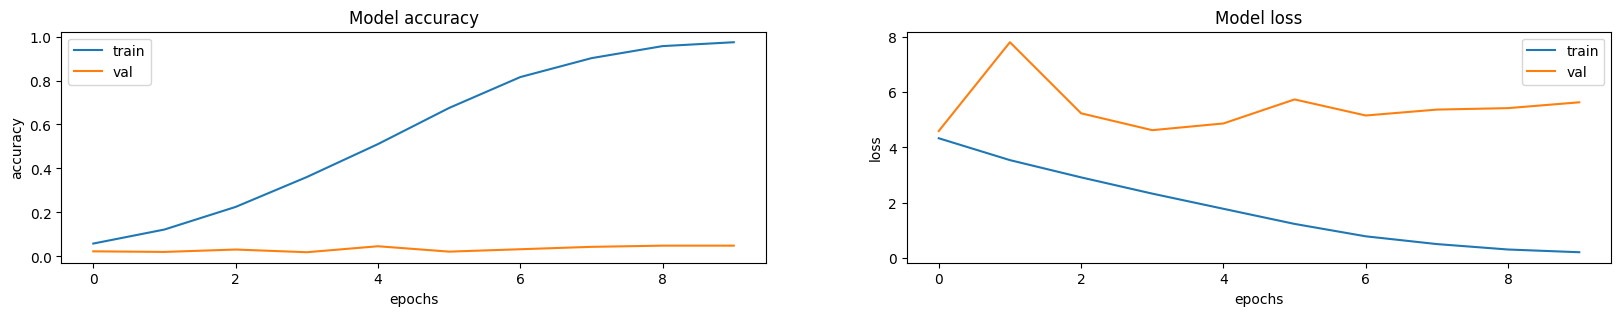

In [ ]:
plt.figure(figsize=(20, 3))
for i, metric in enumerate(["accuracy", "loss"]):
    plt.subplot(1, 2, i + 1) 
    plt.plot(model.history.history[metric])
    plt.plot(model.history.history["val_" + metric])
    plt.title("Model {}".format(metric))
    plt.xlabel("epochs")
    plt.ylabel(metric)
    plt.legend(["train", "val"])

test_loss, test_metric = model.evaluate(x_test, y_test, verbose = 1)
print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")

pred = model.predict(x_test)
print("Test Input Shape: {} Test output shape: {}".format(x_test.shape, pred.shape))


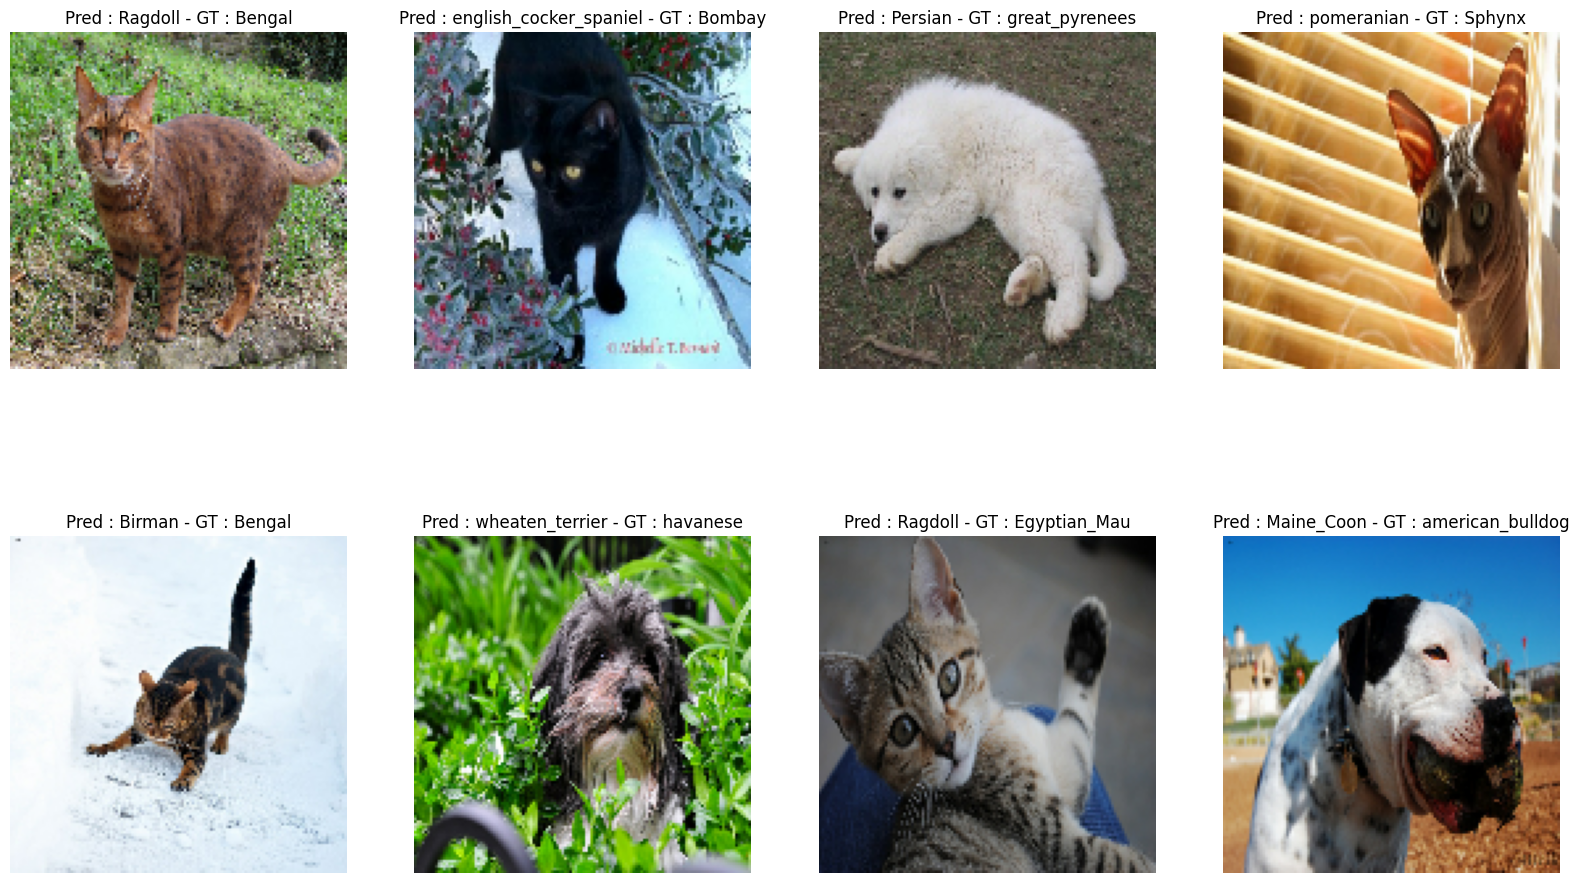

In [ ]:
pred = np.argmax(pred, axis=-1)
y_test = y_test.squeeze()

plt.figure(figsize=(20,12))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    rand_idx = np.random.randint(0, x_test.shape[0])
    plt.axis('off')
    #Qui da errore sul titolo, da mettere a posto
    plt.title(f"Pred : {labels[pred[rand_idx]]} - GT : {labels[y_test[rand_idx]]}")
    plt.imshow(x_test[rand_idx], cmap="gray")
plt.show()